### file for STATS507 Final project

In [7]:
# Step 1: 数据准备与清洗
from datasets import load_dataset
import pandas as pd
# --------------------------
# 1. 加载数据集
# --------------------------
amazon_ds = load_dataset("amazon_polarity", split="train[:20000]")  # 可根据需求扩展样本
tweet_ds = load_dataset("tweet_eval", "sentiment", split="train[:20000]")

# --------------------------
# 2. 创建 pandas DataFrame
# --------------------------
amazon_df = pd.DataFrame({
    "text": amazon_ds["content"],
    "label": amazon_ds["label"]
})
tweet_df = pd.DataFrame({
    "text": tweet_ds["text"],
    "label": tweet_ds["label"]
})

# --------------------------
# 3. 统一标签：三分类 [0 = negative, 1 = neutral, 2 = positive]
# --------------------------
# Amazon: originally 0 = negative, 1 = positive (binary only)
amazon_df["label"] = amazon_df["label"].map({0: 0, 1: 2})  # Map to match TweetEval format

# TweetEval labels already match: 0 = negative, 1 = neutral, 2 = positive

# --------------------------
# 4. 查看样本分布
# --------------------------
print("Amazon Sentiment Counts:\n", amazon_df["label"].value_counts())
print("Tweet Sentiment Counts:\n", tweet_df["label"].value_counts())

# --------------------------
# 5. 每类随机采样 N 条数据，统一样本数（这里取每类 1000）
# --------------------------
N = 1000

def sample_balanced(df, label_col="label", text_col="text", n=N):
    return pd.concat([
        df[df[label_col] == label].sample(n=n, random_state=42)
        for label in sorted(df[label_col].unique())
    ], ignore_index=True)

amazon_sampled = sample_balanced(amazon_df)
tweet_sampled = sample_balanced(tweet_df)

# --------------------------
# 6. 添加 source 字段以区分数据源
# --------------------------
amazon_sampled["source"] = "amazon"
tweet_sampled["source"] = "twitter"

# --------------------------
# 7. 合并为一个总数据集（备用后续可视化）
# --------------------------
df_all = pd.concat([amazon_sampled, tweet_sampled], ignore_index=True)

# --------------------------
# 8. 保存为 CSV（可选）
# --------------------------
df_all.to_csv("sentiment_dataset_balanced.csv", index=False)

# 查看前几行确认
df_all.head()

Amazon Sentiment Counts:
 label
2    10257
0     9743
Name: count, dtype: int64
Tweet Sentiment Counts:
 label
1    9020
2    7831
0    3149
Name: count, dtype: int64


,text,label,source
0,I intended to use this TiVo with an AT&T Uvers...,0,amazon
1,A complete disappointment and waste of time. T...,0,amazon
2,This book leaves much to be desired. Take the ...,0,amazon
3,"Very simplistic writing style- he said, she sa...",0,amazon
4,"i have always been a fan of romantic comedies,...",0,amazon


In [9]:
from transformers import pipeline
from tqdm import tqdm

# --------------------------
# 1. 加载 sentiment-analysis 模型
# --------------------------
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# --------------------------
# 2. 创建预测函数
# --------------------------
def run_sentiment_analysis(text_list):
    results = sentiment_pipeline(text_list, truncation=True, batch_size=16)
    return results

# --------------------------
# 3. 批量预测（建议使用 tqdm 展示进度条）
# --------------------------
texts = df_all["text"].tolist()
predictions = []

for i in tqdm(range(0, len(texts), 16)):
    batch = texts[i:i+16]
    preds = run_sentiment_analysis(batch)
    predictions.extend(preds)

# --------------------------
# 4. 将预测结果写入 DataFrame
# --------------------------
df_all["pred_label"] = [p["label"] for p in predictions]
df_all["pred_score"] = [p["score"] for p in predictions]

# --------------------------
# 5. 显示前几行
# --------------------------
df_all.head()

Device set to use cpu
100%|██████████| 313/313 [02:41<00:00,  1.94it/s]


,text,label,source,pred_label,pred_score
0,I intended to use this TiVo with an AT&T Uvers...,0,amazon,NEGATIVE,0.999435
1,A complete disappointment and waste of time. T...,0,amazon,NEGATIVE,0.999799
2,This book leaves much to be desired. Take the ...,0,amazon,NEGATIVE,0.996767
3,"Very simplistic writing style- he said, she sa...",0,amazon,POSITIVE,0.985427
4,"i have always been a fan of romantic comedies,...",0,amazon,NEGATIVE,0.999562


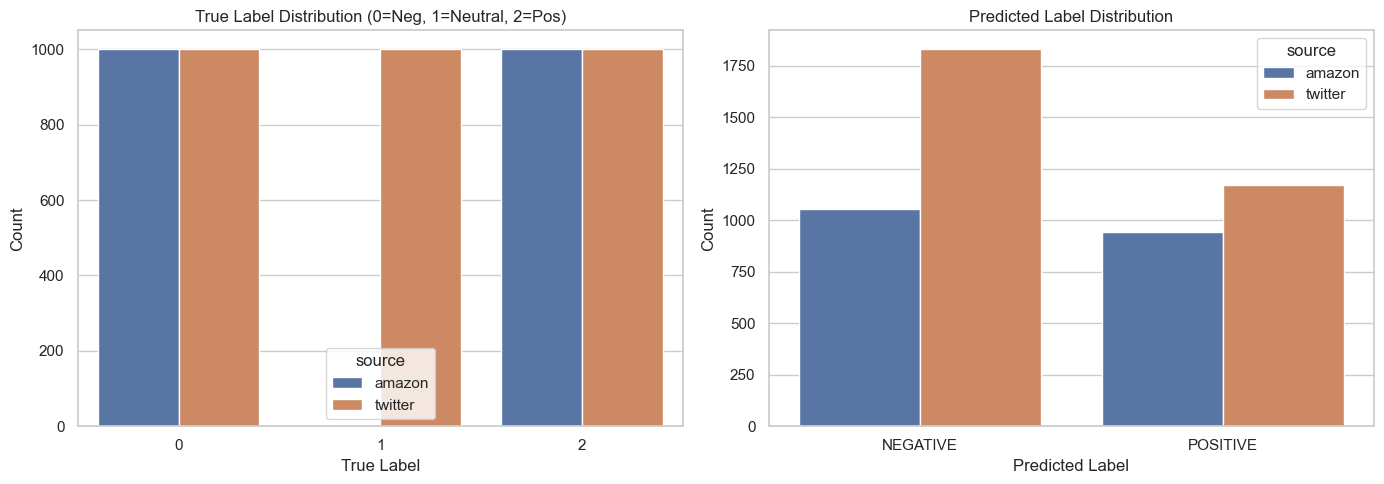

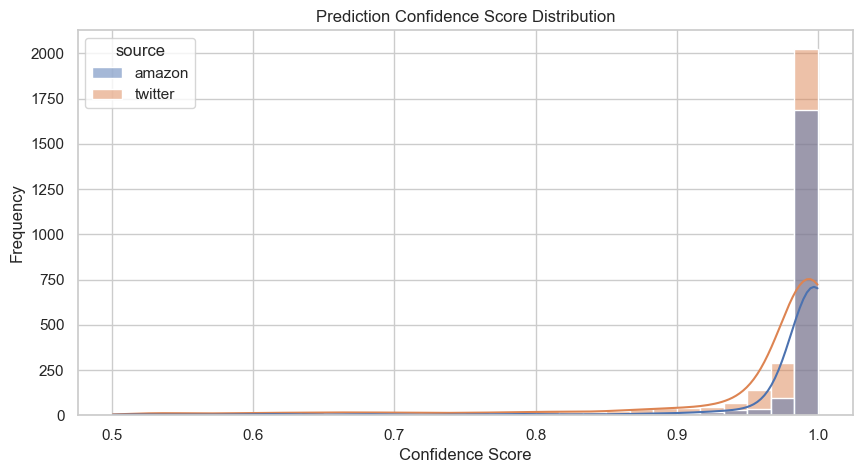

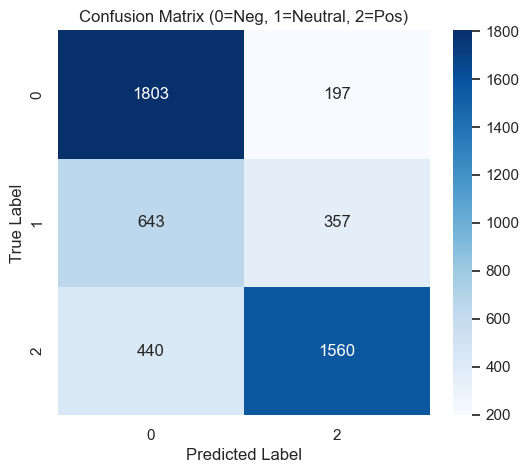

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置图像风格
sns.set(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

# ========== 1. 情绪标签分布图（真实标签 vs 预测标签） ==========
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_all, x="label", hue="source", ax=axes[0])
axes[0].set_title("True Label Distribution (0=Neg, 1=Neutral, 2=Pos)")
axes[0].set_xlabel("True Label")
axes[0].set_ylabel("Count")

sns.countplot(data=df_all, x="pred_label", hue="source", ax=axes[1])
axes[1].set_title("Predicted Label Distribution")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ========== 2. 模型置信度分布图 ==========
plt.figure(figsize=(10, 5))
sns.histplot(data=df_all, x="pred_score", hue="source", kde=True, bins=30)
plt.title("Prediction Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

# ========== 3. 混淆矩阵图（真实标签 vs 预测标签） ==========
# 映射预测标签为数字（便于计算）
label_map = {"NEGATIVE": 0, "POSITIVE": 2}
df_all["pred_label_id"] = df_all["pred_label"].map(label_map)

conf_matrix = pd.crosstab(df_all["label"], df_all["pred_label_id"], rownames=["True"], colnames=["Predicted"])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (0=Neg, 1=Neutral, 2=Pos)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [15]:
df_all.groupby(["source", "label"]).size()

source   label
amazon   0        1000
         2        1000
twitter  0        1000
         1        1000
         2        1000
dtype: int64

In [19]:
from sklearn.metrics import classification_report

# 混淆矩阵中，我们只关注 NEGATIVE（0）和 POSITIVE（2）
# 因为模型输出中没有 NEUTRAL 类（模型是二分类的）

# 删除真实标签为 1（neutral）的样本
df_binary = df_all[df_all["label"] != 1].copy()

# 再次转换 pred_label 为数字
label_map = {"NEGATIVE": 0, "POSITIVE": 2}
df_binary["pred_label_id"] = df_binary["pred_label"].map(label_map)

# 打印报告
report = classification_report(
    df_binary["label"],
    df_binary["pred_label_id"],
    target_names=["Negative", "Positive"]
)

print("Binary Sentiment Classification Report (Excluding Neutral Class):\n")
print(report)

# 可选：保存包含预测的完整数据集
df_all.to_csv("sentiment_with_predictions.csv", index=False)

Binary Sentiment Classification Report (Excluding Neutral Class):

              precision    recall  f1-score   support

    Negative       0.80      0.90      0.85      2000
    Positive       0.89      0.78      0.83      2000

    accuracy                           0.84      4000
   macro avg       0.85      0.84      0.84      4000
weighted avg       0.85      0.84      0.84      4000

